Mounted at /content/drive


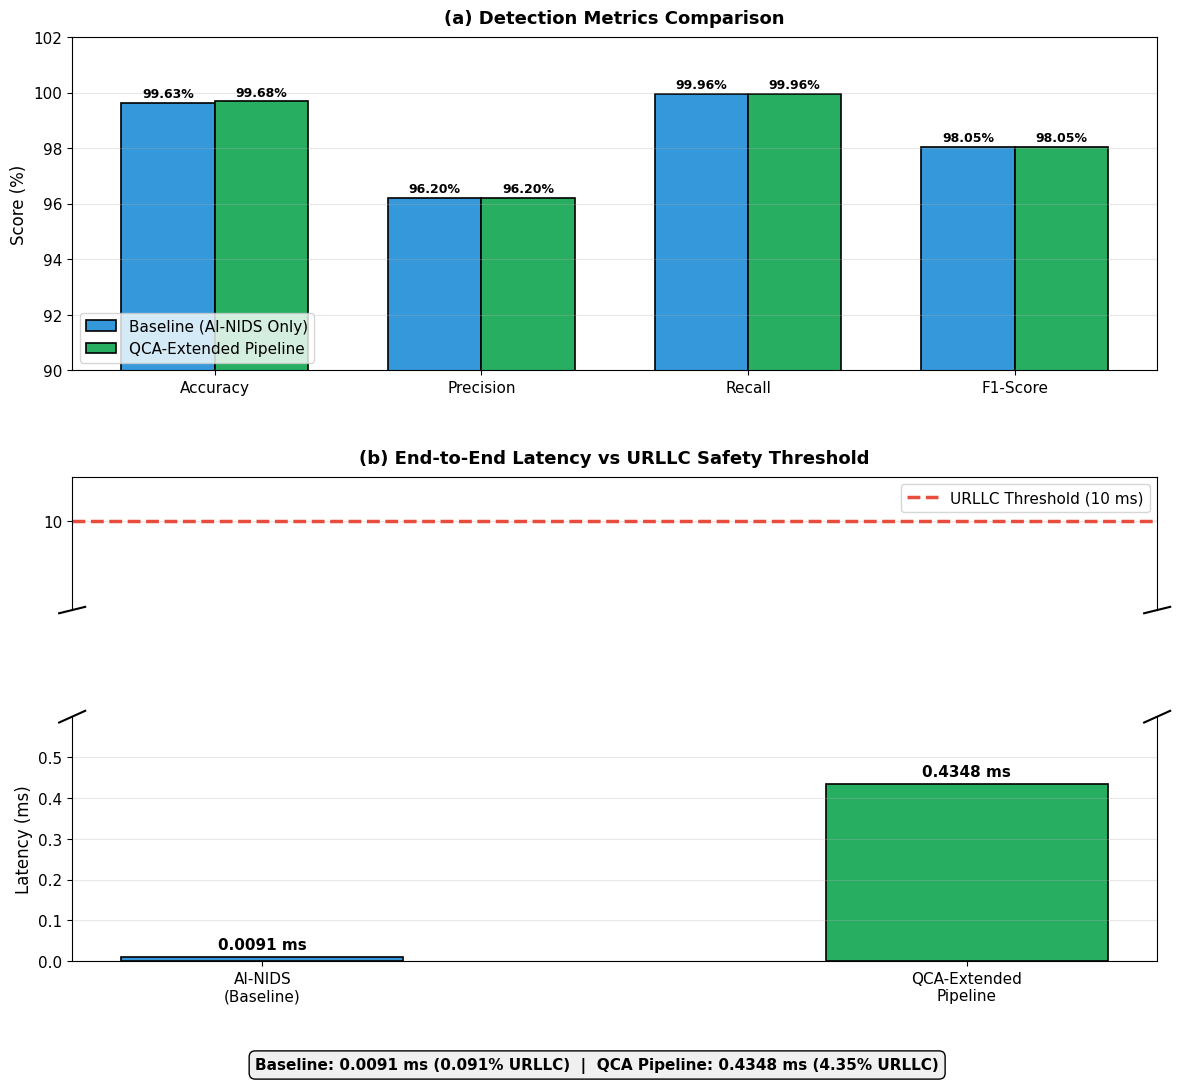

Saved: /content/drive/MyDrive/veremi_thesis/figure_comparison_github.png


In [1]:
# ============================================================
# Figure 5.3: Side-by-Side Comparison (Baseline vs QCA)
# GitHub version (with (a) and (b) panel titles)
# ============================================================

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Imports
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

# ============================================================
# CONFIGURATION
# ============================================================
BASELINE_COLOR = "#3498db"
QCA_COLOR = "#27ae60"
THRESHOLD_COLOR = "#e74c3c"

# Locked empirical values
baseline_metrics = [99.6277, 96.2045, 99.9626, 98.0476]
qca_metrics = [99.68, 96.20, 99.96, 98.05]
metric_labels = ["Accuracy", "Precision", "Recall", "F1-Score"]
baseline_latency = 0.0091
qca_latency = 0.4348
urllc_threshold = 10.0

# ============================================================
# CREATE FIGURE
# ============================================================
fig = plt.figure(figsize=(14, 12))
gs = GridSpec(3, 1, figure=fig, height_ratios=[3, 1.2, 2.2], hspace=0.45)

# Top panel: Detection Metrics Comparison (grouped bars)
ax1 = fig.add_subplot(gs[0])
x = np.arange(len(metric_labels))
width = 0.35

bars1 = ax1.bar(x - width/2, baseline_metrics, width,
                label="Baseline (AI-NIDS Only)",
                color=BASELINE_COLOR, edgecolor="black", linewidth=1.2)
bars2 = ax1.bar(x + width/2, qca_metrics, width,
                label="QCA-Extended Pipeline",
                color=QCA_COLOR, edgecolor="black", linewidth=1.2)
ax1.set_ylabel("Score (%)", fontsize=12)
ax1.set_title("(a) Detection Metrics Comparison", fontsize=13, fontweight="bold", pad=10)
ax1.set_xticks(x)
ax1.set_xticklabels(metric_labels, fontsize=11)
ax1.set_ylim(90, 102)
ax1.legend(loc="lower left", fontsize=11)
ax1.grid(axis="y", alpha=0.3)
ax1.tick_params(axis='y', labelsize=11)
for bars, vals in [(bars1, baseline_metrics), (bars2, qca_metrics)]:
    for bar, val in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2, val + 0.2,
                 f"{val:.2f}%", ha="center", fontsize=9, fontweight="bold")

# Middle panel: URLLC zone (8-11 ms)
latency_labels = ["AI-NIDS\n(Baseline)", "QCA-Extended\nPipeline"]
latency_values = [baseline_latency, qca_latency]
latency_colors = [BASELINE_COLOR, QCA_COLOR]

ax2_upper = fig.add_subplot(gs[1])
ax2_upper.bar(latency_labels, latency_values, color=latency_colors,
              edgecolor="black", linewidth=1.2, width=0.4)
ax2_upper.axhline(y=urllc_threshold, color=THRESHOLD_COLOR, linestyle="--",
                  linewidth=2.5, label="URLLC Threshold (10 ms)")
ax2_upper.set_ylim(8, 11)
ax2_upper.spines['bottom'].set_visible(False)
ax2_upper.tick_params(labelbottom=False, bottom=False)
ax2_upper.set_title("(b) End-to-End Latency vs URLLC Safety Threshold",
                    fontsize=13, fontweight="bold", pad=10)
ax2_upper.legend(loc="upper right", fontsize=11)
ax2_upper.grid(axis="y", alpha=0.3)
ax2_upper.tick_params(axis='y', labelsize=11)
ax2_upper.set_yticks([10])
ax2_upper.set_yticklabels(["10"])

# Bottom panel: Zoomed latency (0-0.6 ms)
ax2_lower = fig.add_subplot(gs[2])
bars3 = ax2_lower.bar(latency_labels, latency_values, color=latency_colors,
                      edgecolor="black", linewidth=1.2, width=0.4)
ax2_lower.set_ylabel("Latency (ms)", fontsize=12)
ax2_lower.set_ylim(0, 0.6)
ax2_lower.spines['top'].set_visible(False)
ax2_lower.grid(axis="y", alpha=0.3)
ax2_lower.tick_params(axis='both', labelsize=11)
ax2_lower.set_yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5])
ax2_lower.set_yticklabels(["0.0", "0.1", "0.2", "0.3", "0.4", "0.5"])

for bar, val in zip(bars3, latency_values):
    ax2_lower.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                   f"{val} ms", ha="center", fontsize=11, fontweight="bold")

# Break marks
d = 0.012
kwargs = dict(transform=ax2_upper.transAxes, color='k', clip_on=False, linewidth=1.5)
ax2_upper.plot((-d, +d), (-d * 2, +d * 2), **kwargs)
ax2_upper.plot((1 - d, 1 + d), (-d * 2, +d * 2), **kwargs)
kwargs.update(transform=ax2_lower.transAxes)
ax2_lower.plot((-d, +d), (1 - d * 2, 1 + d * 2), **kwargs)
ax2_lower.plot((1 - d, 1 + d), (1 - d * 2, 1 + d * 2), **kwargs)

# Summary annotation
baseline_budget = (baseline_latency / urllc_threshold) * 100
qca_budget = (qca_latency / urllc_threshold) * 100
fig.text(0.5, 0.02,
         f"Baseline: {baseline_latency} ms ({baseline_budget:.3f}% URLLC)  |  "
         f"QCA Pipeline: {qca_latency} ms ({qca_budget:.2f}% URLLC)",
         ha="center", fontsize=11, fontweight="bold",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#f0f0f0", edgecolor="black"))

# ============================================================
# SAVE AND DISPLAY
# ============================================================
output_path = "/content/drive/MyDrive/veremi_thesis/figure_comparison_github.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {output_path}")